# Stroke Prediction — Exploratory Data Analysis
**Goal:** Understand the dataset structure, distributions, missing values, and class imbalance before any modelling.

Notebook order:
1. `01_eda.ipynb` ← you are here
2. `02_preprocessing.ipynb`
3. `03_model_training.ipynb`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Consistent plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

DATA_PATH = '../data/raw/healthcare-dataset-stroke-data.csv'
df = pd.read_csv(DATA_PATH)
print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

Dataset loaded: 5,110 rows × 12 columns


---
## 1. First look

In [2]:
df.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,5110.0,NaN,NaN,NaN,36517.829354,21161.721625,67.0,17741.25,36932.0,54682.0,72940.0
gender,5110,3,Female,2994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,5110.0,NaN,NaN,NaN,43.226614,22.612647,0.08,25.0,45.0,61.0,82.0
hypertension,5110.0,NaN,NaN,NaN,0.097456,0.296607,0.0,0.0,0.0,0.0,1.0
heart_disease,5110.0,NaN,NaN,NaN,0.054012,0.226063,0.0,0.0,0.0,0.0,1.0
ever_married,5110,2,Yes,3353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
work_type,5110,5,Private,2925,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Residence_type,5110,2,Urban,2596,NaN,NaN,NaN,NaN,NaN,NaN,NaN
avg_glucose_level,5110.0,NaN,NaN,NaN,106.147677,45.28356,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,NaN,NaN,NaN,28.893237,7.854067,10.3,23.5,28.1,33.1,97.6


---
## 2. Missing values

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0]

print('Columns with missing values:')
print(missing_df if len(missing_df) > 0 else 'None')

Columns with missing values:
     missing_count  missing_%
bmi            201       3.93


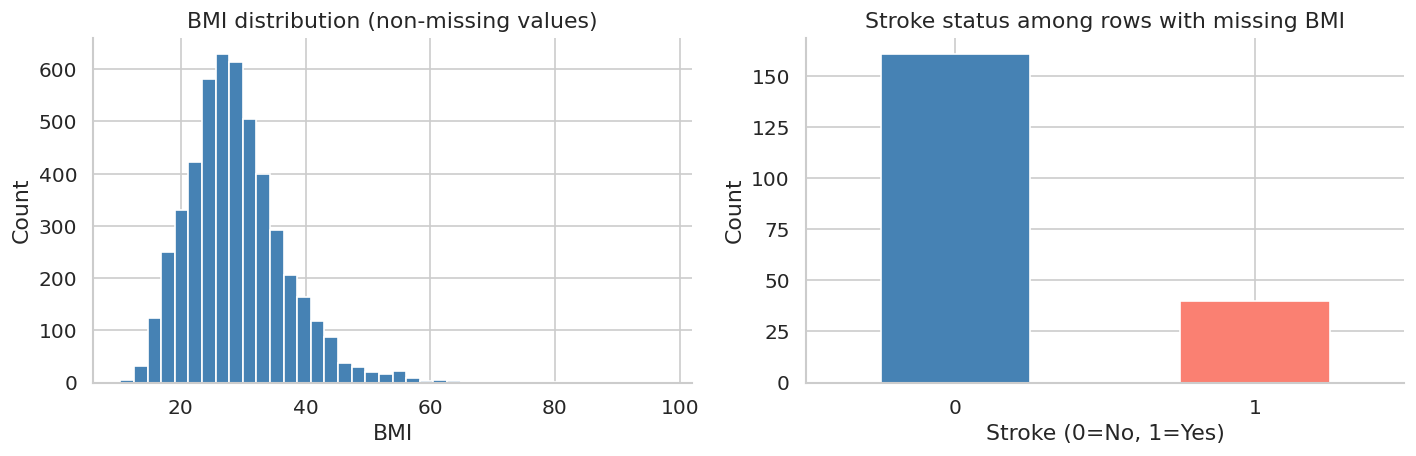

Missing BMI rows: 201 (3.93%)


In [6]:
if 'bmi' in missing_df.index:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Distribution of BMI (non-missing)
    df['bmi'].dropna().hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white')
    axes[0].set_title('BMI distribution (non-missing values)')
    axes[0].set_xlabel('BMI')
    axes[0].set_ylabel('Count')

    # BMI missing vs stroke
    bmi_missing_stroke = df[df['bmi'].isnull()]['stroke'].value_counts()
    bmi_missing_stroke.plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'], edgecolor='white')
    axes[1].set_title('Stroke status among rows with missing BMI')
    axes[1].set_xlabel('Stroke (0=No, 1=Yes)')
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.savefig('../data/processed/eda_bmi_missing.png', bbox_inches='tight')
    plt.show()
    print(f"Missing BMI rows: {missing_df.loc['bmi', 'missing_count']} ({missing_df.loc['bmi', 'missing_%']}%)")

---
## 3. Class imbalance — the core problem

In [7]:
stroke_counts = df['stroke'].value_counts()
stroke_pct = df['stroke'].value_counts(normalize=True) * 100

print('Stroke class distribution:')
print(pd.DataFrame({'count': stroke_counts, '%': stroke_pct.round(2)}))
print(f'\nImbalance ratio: {stroke_counts[0] / stroke_counts[1]:.1f}:1 (no stroke : stroke)')

Stroke class distribution:
        count      %
stroke              
0        4861  95.13
1         249   4.87

Imbalance ratio: 19.5:1 (no stroke : stroke)


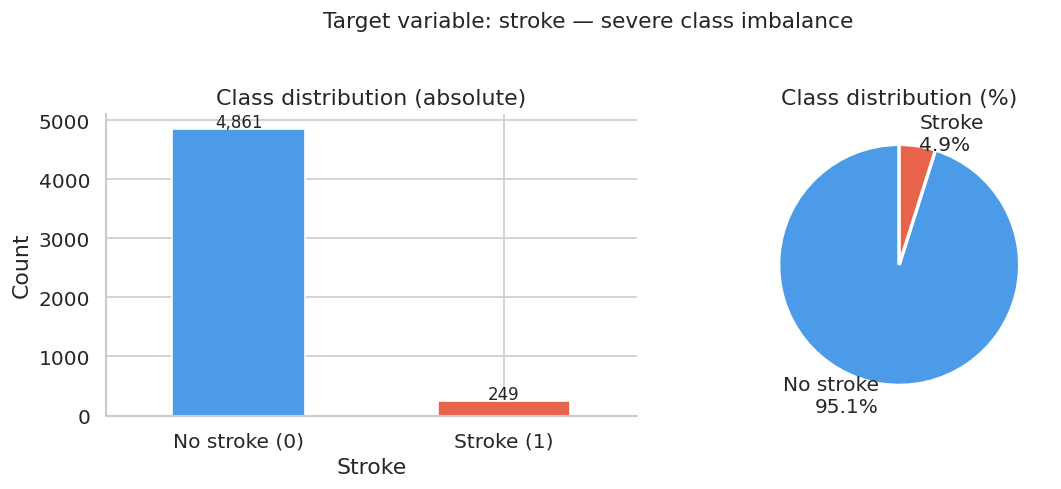

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
colors = ['#4C9BE8', '#E8634C']
stroke_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Class distribution (absolute)')
axes[0].set_xlabel('Stroke')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No stroke (0)', 'Stroke (1)'], rotation=0)
for i, v in enumerate(stroke_counts):
    axes[0].text(i, v + 20, f'{v:,}', ha='center', fontsize=10)

# Pie chart
axes[1].pie(
    stroke_pct,
    labels=[f'No stroke\n{stroke_pct[0]:.1f}%', f'Stroke\n{stroke_pct[1]:.1f}%'],
    colors=colors,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[1].set_title('Class distribution (%)')

plt.suptitle('Target variable: stroke — severe class imbalance', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/eda_class_imbalance.png', bbox_inches='tight')
plt.show()

---
## 4. Categorical feature distributions

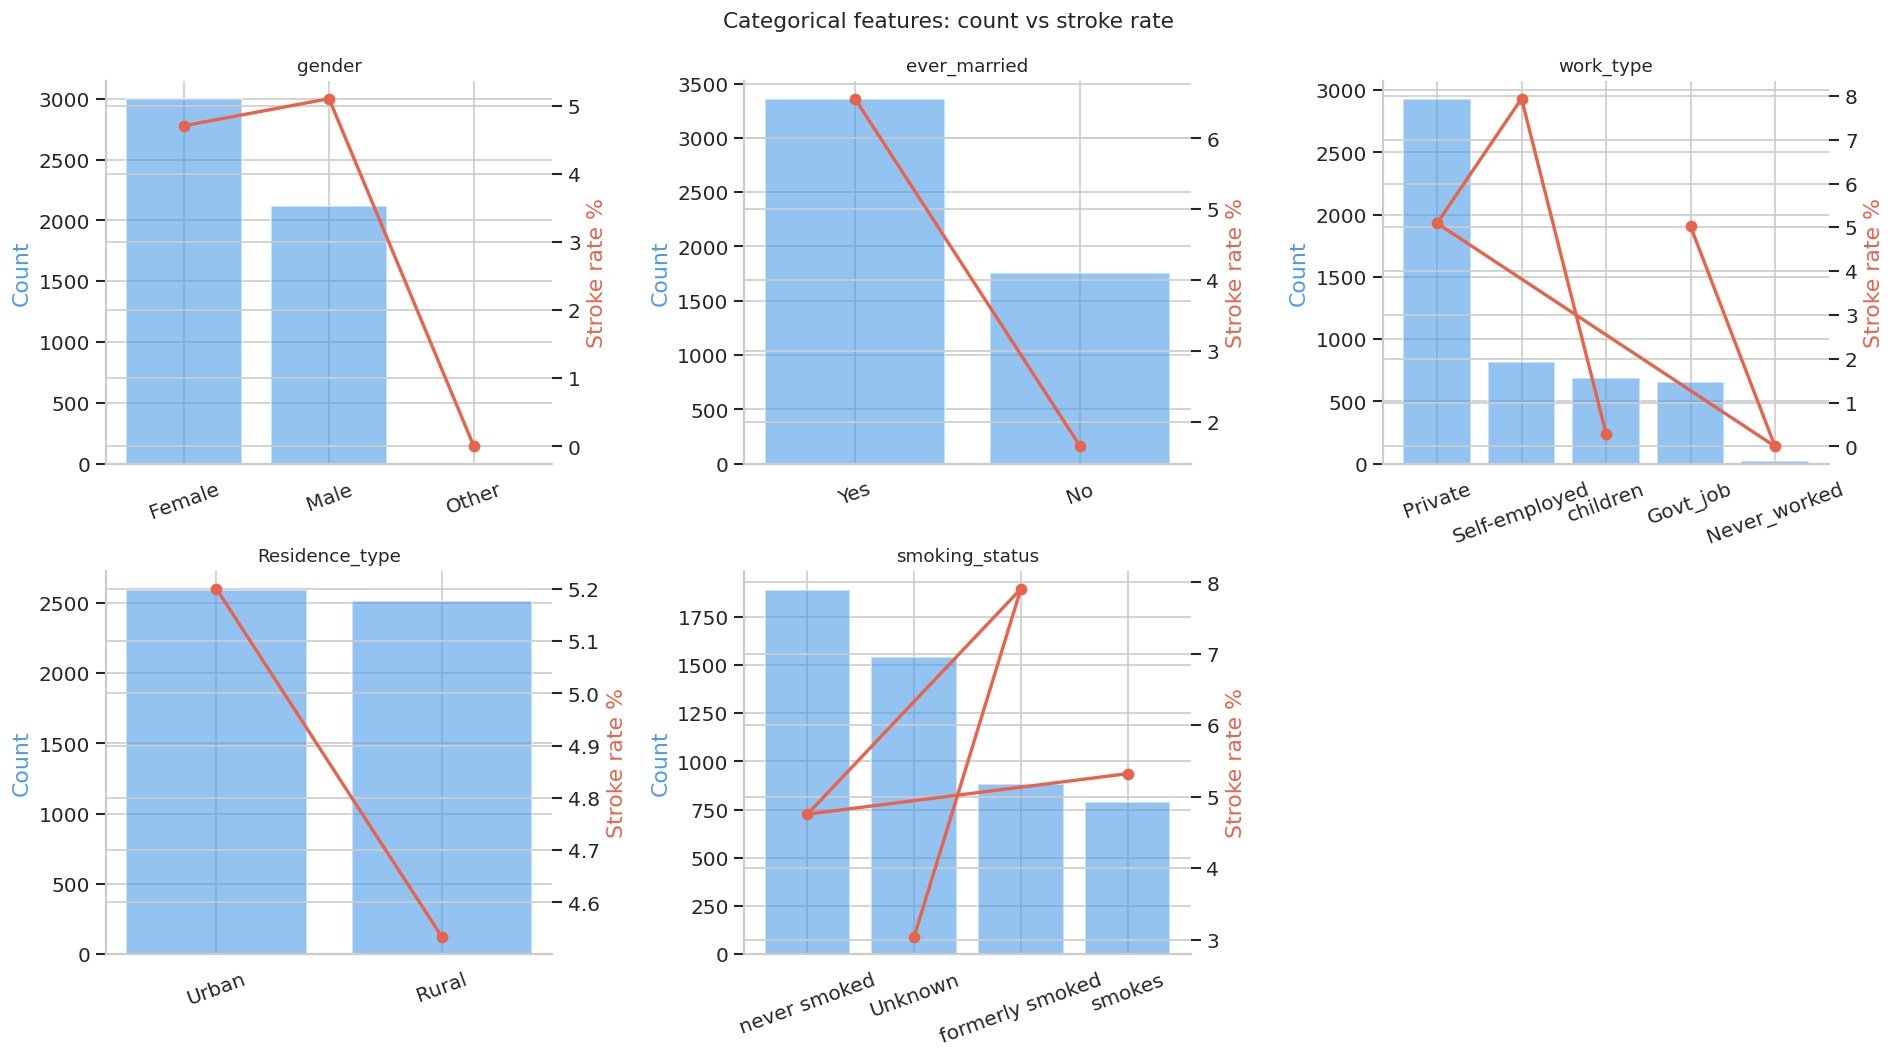

In [9]:
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    stroke_rate = df.groupby(col)['stroke'].mean() * 100
    counts = df[col].value_counts()

    ax1 = axes[i]
    ax2 = ax1.twinx()

    bars = ax1.bar(counts.index, counts.values, color='#4C9BE8', alpha=0.6,
                   edgecolor='white', label='Count')
    ax2.plot(stroke_rate.index, stroke_rate.values, 'o-', color='#E8634C',
             linewidth=2, markersize=6, label='Stroke rate %')

    ax1.set_title(col, fontsize=11)
    ax1.set_ylabel('Count', color='#4C9BE8')
    ax2.set_ylabel('Stroke rate %', color='#E8634C')
    ax1.tick_params(axis='x', rotation=20)

# Hide unused subplot
axes[-1].set_visible(False)

plt.suptitle('Categorical features: count vs stroke rate', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/eda_categorical.png', bbox_inches='tight')
plt.show()

---
## 5. Numerical feature distributions

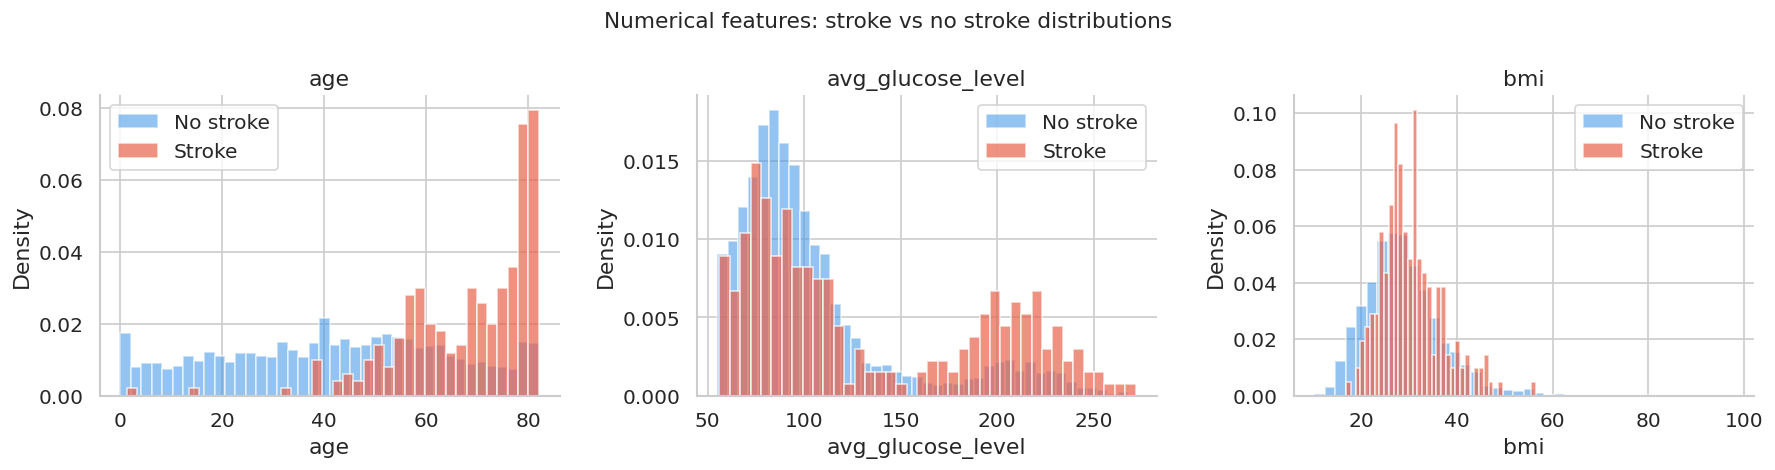

In [10]:
num_cols = ['age', 'avg_glucose_level', 'bmi']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, num_cols):
    df[df['stroke'] == 0][col].dropna().hist(
        bins=40, ax=ax, alpha=0.6, color='#4C9BE8', label='No stroke', density=True)
    df[df['stroke'] == 1][col].dropna().hist(
        bins=40, ax=ax, alpha=0.7, color='#E8634C', label='Stroke', density=True)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Numerical features: stroke vs no stroke distributions', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/eda_numerical.png', bbox_inches='tight')
plt.show()

---
## 6. Correlation heatmap

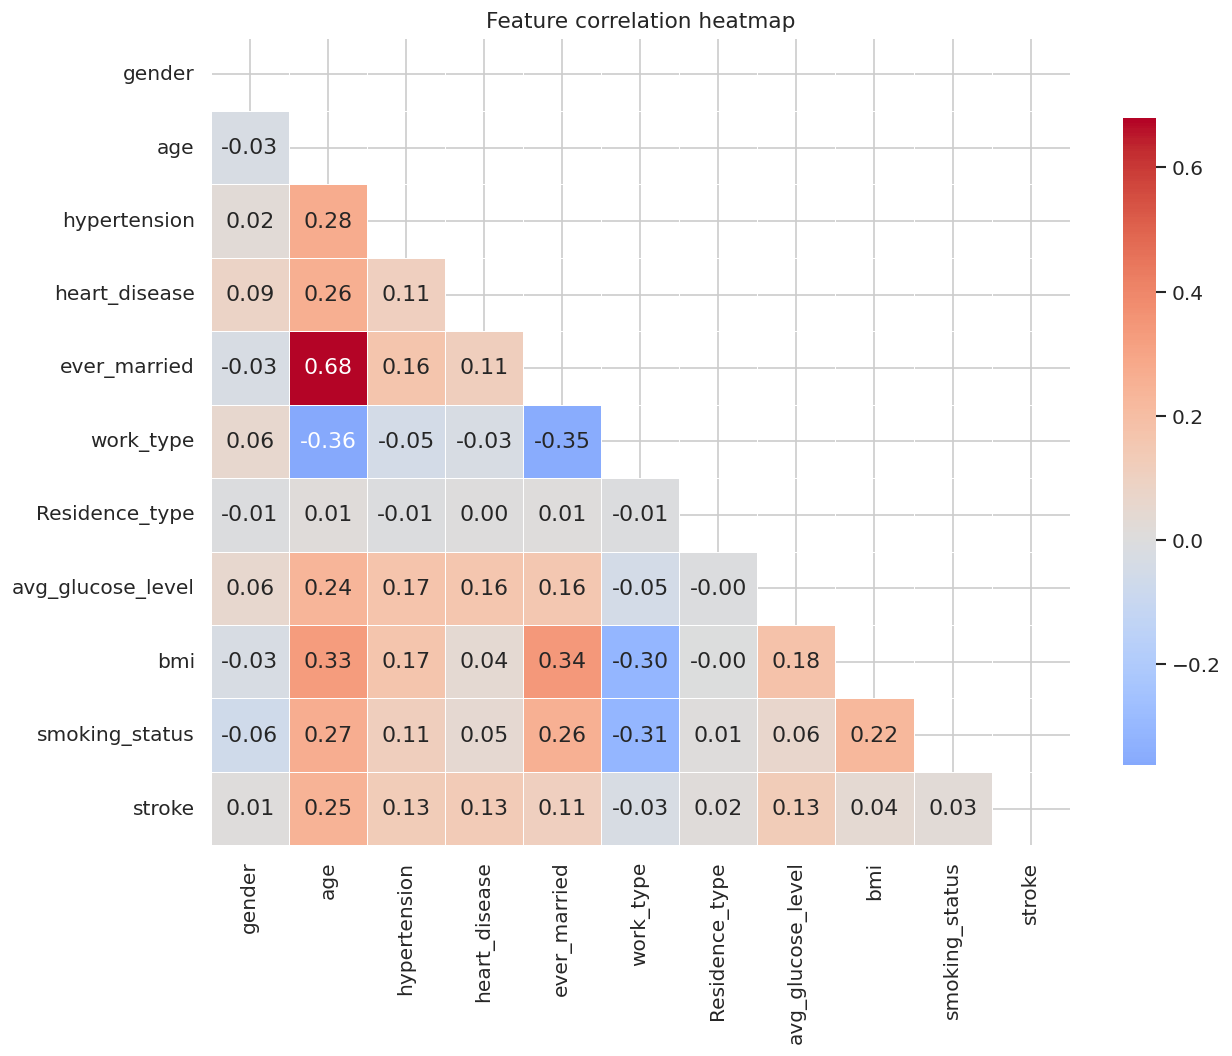

In [11]:
# Encode categoricals temporarily for correlation
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = pd.Categorical(df_encoded[col]).codes

corr = df_encoded.drop(columns=['id']).corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature correlation heatmap', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/eda_correlation.png', bbox_inches='tight')
plt.show()

---
## 7. Stroke rate by age group

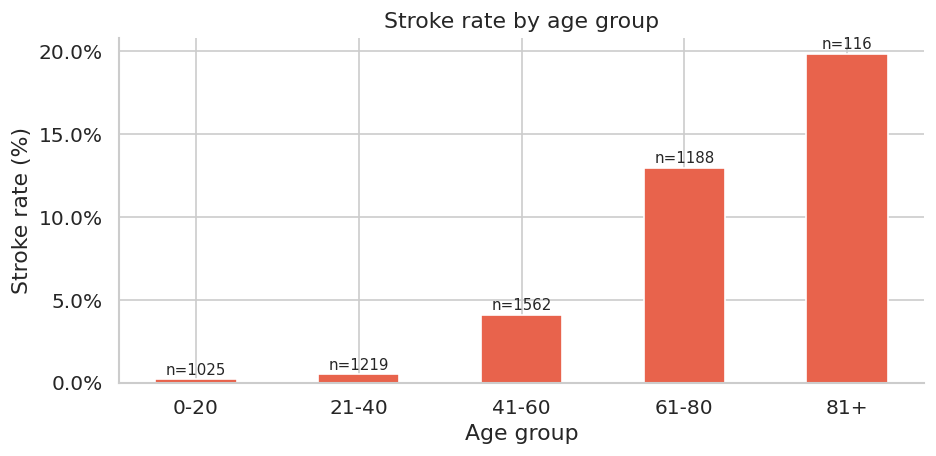

In [12]:
df['age_group'] = pd.cut(df['age'], bins=[0, 20, 40, 60, 80, 100],
                          labels=['0-20', '21-40', '41-60', '61-80', '81+'])

age_stroke = df.groupby('age_group')['stroke'].agg(['mean', 'count']).reset_index()
age_stroke['mean'] *= 100

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(age_stroke['age_group'].astype(str), age_stroke['mean'],
              color='#E8634C', edgecolor='white', width=0.5)
for bar, count in zip(bars, age_stroke['count']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'n={count}', ha='center', fontsize=9)

ax.set_title('Stroke rate by age group')
ax.set_xlabel('Age group')
ax.set_ylabel('Stroke rate (%)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
plt.tight_layout()
plt.savefig('../data/processed/eda_age_stroke.png', bbox_inches='tight')
plt.show()

# Drop temp column
df.drop(columns=['age_group'], inplace=True)

---
## 8. Key takeaways

Run this cell to get a summary of findings to carry into preprocessing.

In [13]:
print('=' * 55)
print('EDA SUMMARY — carry these into 02_preprocessing.ipynb')
print('=' * 55)

print(f"""
Dataset
  Rows         : {len(df):,}
  Features     : {df.shape[1] - 2} (excl. id + target)
  Target       : stroke (binary)

Class imbalance
  No stroke    : {stroke_counts[0]:,} ({stroke_pct[0]:.1f}%)
  Stroke       : {stroke_counts[1]:,} ({stroke_pct[1]:.1f}%)
  Ratio        : {stroke_counts[0]/stroke_counts[1]:.0f}:1  ← fix with SMOTE

Missing values
  bmi          : {df['bmi'].isnull().sum()} rows ({df['bmi'].isnull().mean()*100:.1f}%)  ← impute with median

Categorical columns to encode
  gender, ever_married, work_type,
  Residence_type, smoking_status

Columns to drop
  id           : unique identifier, no predictive value

Notable patterns
  - Age is the strongest predictor (stroke rare under 40)
  - High glucose level correlates with stroke
  - Hypertension + heart disease are important risk flags
""")
print('=' * 55)

EDA SUMMARY — carry these into 02_preprocessing.ipynb

Dataset
  Rows         : 5,110
  Features     : 10 (excl. id + target)
  Target       : stroke (binary)

Class imbalance
  No stroke    : 4,861 (95.1%)
  Stroke       : 249 (4.9%)
  Ratio        : 20:1  ← fix with SMOTE

Missing values
  bmi          : 201 rows (3.9%)  ← impute with median

Categorical columns to encode
  gender, ever_married, work_type,
  Residence_type, smoking_status

Columns to drop
  id           : unique identifier, no predictive value

Notable patterns
  - Age is the strongest predictor (stroke rare under 40)
  - High glucose level correlates with stroke
  - Hypertension + heart disease are important risk flags

